# UDFPS Stack Structure Visualization

v6 Section 2: UDFPS COE 스택 구조를 시각화하고 PINN 도메인을 이해합니다.

## Contents
1. Full Stack (Finger → OPD) + Pipeline stages
2. Pipeline Diagram (TMM → ASM → PINN → PSF)
3. PINN Domain Zoom (z=0~40μm) + BM slit geometry
4. Design Variable 인터랙티브 탐색

In [1]:
import sys
from pathlib import Path

def _find_root():
    p = Path.cwd().resolve()
    for _ in range(10):
        if (p / 'pyproject.toml').exists():
            return p
        p = p.parent
    raise FileNotFoundError('Cannot find project root')

PROJECT_ROOT = _find_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
%matplotlib inline

from notebooks.helpers.visualization import (
    plot_full_stack, plot_pinn_domain, plot_pipeline
)
print(f'Project: {PROJECT_ROOT.name}')

Project: AI_PINN_PROJECT_v03


---
## 1. Full UDFPS Stack

v6 Section 2.1: Finger → AR → CG → BM2 → ILD → BM1 → Encap → OPD

오른쪽에 각 영역을 담당하는 **파이프라인 스테이지** (TMM / ASM / PINN)가 표시됩니다.

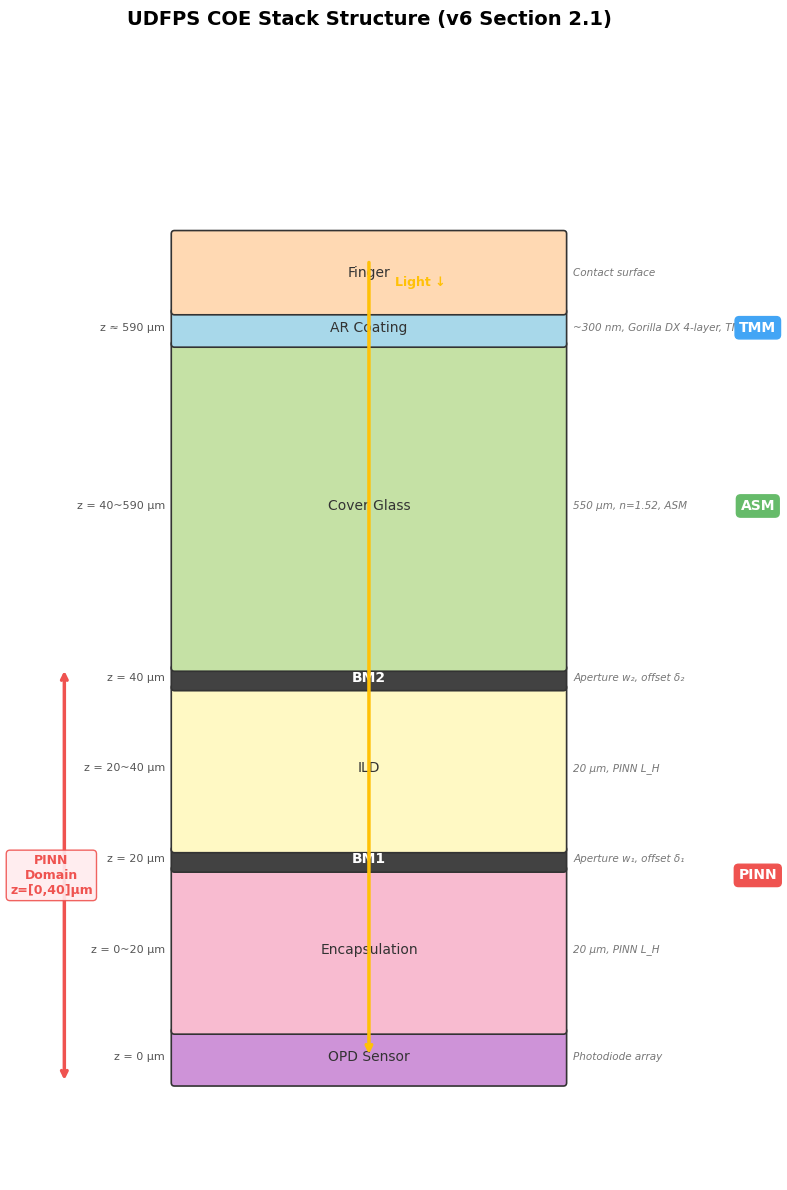

In [2]:
fig, ax = plot_full_stack(figsize=(10, 12))
plt.show()

---
## 2. Pipeline Diagram

v6 Section 3.1:
```
TMM (AR ~300nm) → ASM (CG 550μm) → PINN (BM~OPD 40μm) → PSF (7 pixels)
```

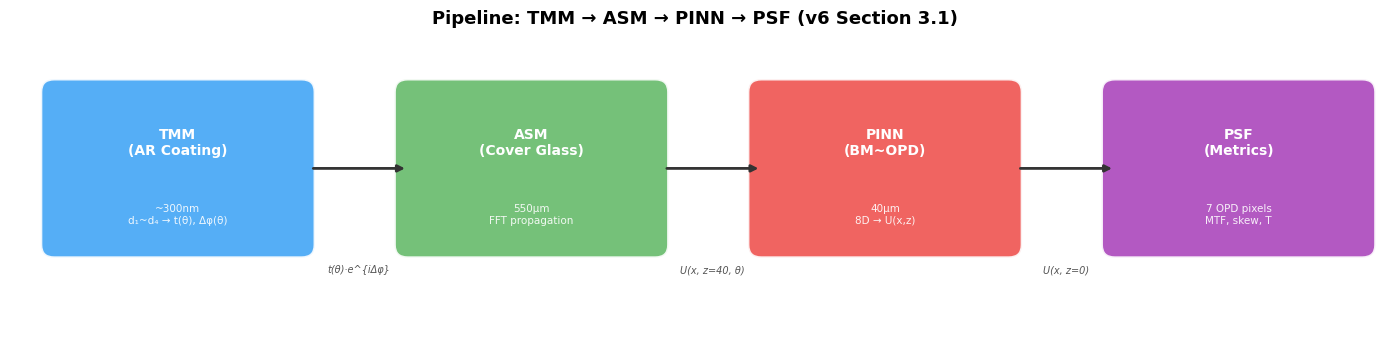

In [3]:
fig, ax = plot_pipeline(figsize=(14, 3.5))
plt.show()

---
## 3. PINN Domain (z=0~40μm)

v6 Section 2.3, 4.2:
- **BM2** (z=40): 입사 경계, slit 내부 = L_phase, 외부 = L_BC (U=0)
- **ILD** (z=20~40): 회절 전파 영역, L_Helmholtz
- **BM1** (z=20): 2차 회절 경계, L_BC (U=0)
- **Encap** (z=0~20): 최종 전파, L_Helmholtz
- **OPD** (z=0): 센서 면, PSF 측정

### 기본 설계변수 (δ₁=0, δ₂=0, w₁=10, w₂=10)

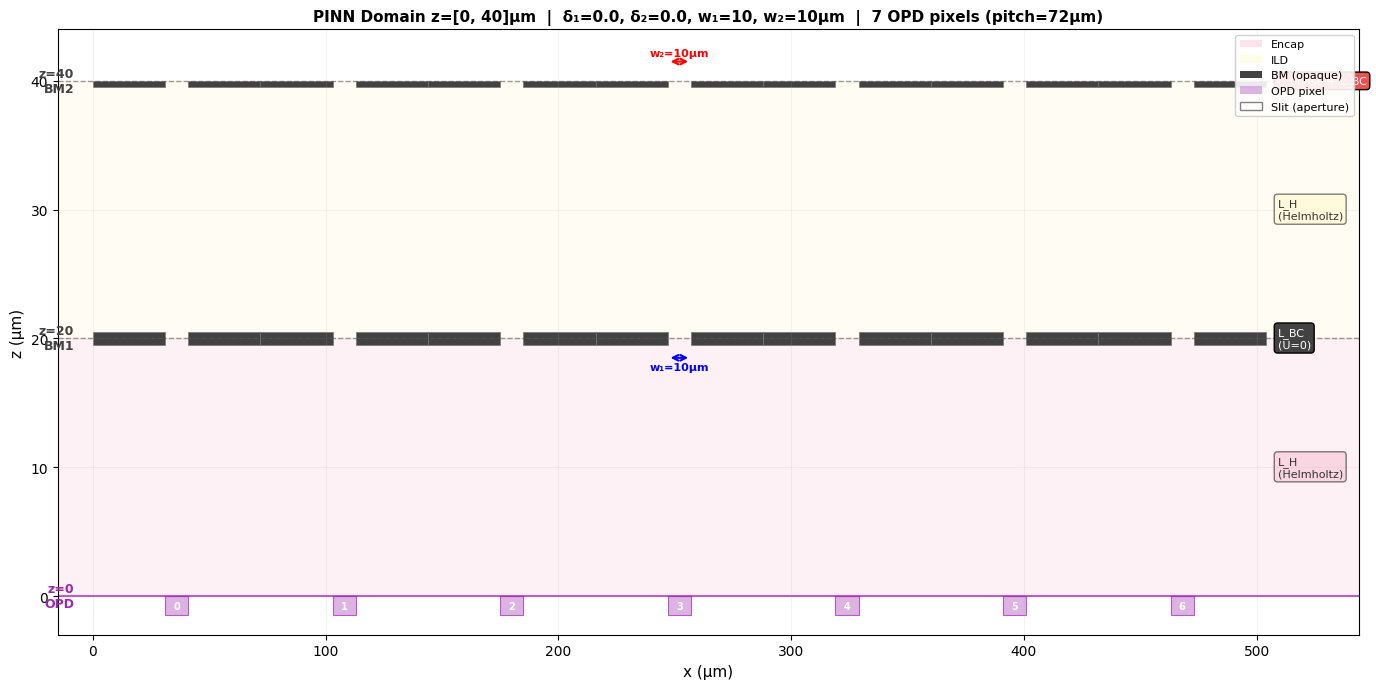

In [4]:
fig, ax = plot_pinn_domain(
    delta_bm1=0, delta_bm2=0, w1=10, w2=10,
    figsize=(14, 7)
)
plt.show()

---
## 4. Design Variable Effects

v6 Section 2.5: 설계변수 4개
- `delta_bm1`: BM1 오프셋 [-10, 10] μm
- `delta_bm2`: BM2 오프셋 [-10, 10] μm
- `w1`: BM1 아퍼처 폭 [5, 20] μm
- `w2`: BM2 아퍼처 폭 [5, 20] μm

### 4a. Offset 효과: δ₁=5, δ₂=-5 (비대칭 BM)

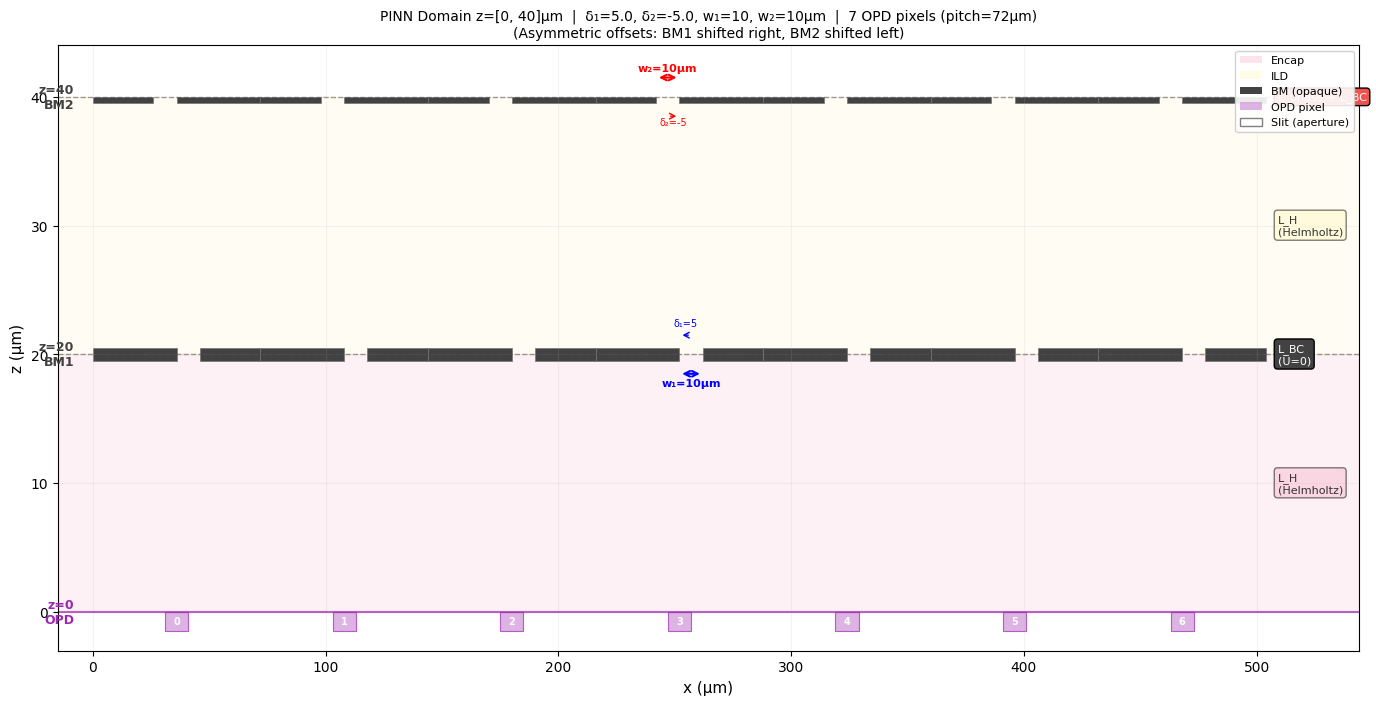

In [5]:
fig, ax = plot_pinn_domain(
    delta_bm1=5, delta_bm2=-5, w1=10, w2=10,
    figsize=(14, 7)
)
ax.set_title(ax.get_title() + '\n(Asymmetric offsets: BM1 shifted right, BM2 shifted left)',
             fontsize=10)
plt.show()

### 4b. Aperture 효과: w₁=5 (좁음), w₂=20 (넓음)

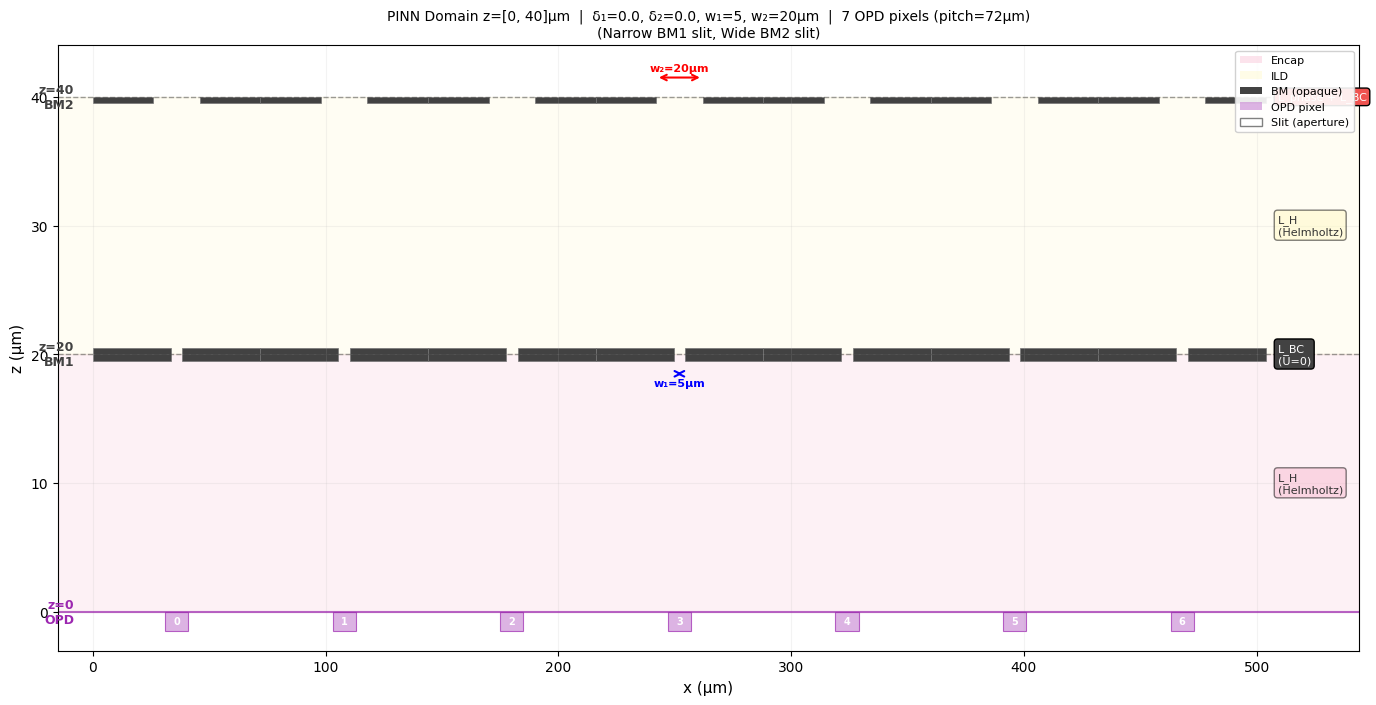

In [6]:
fig, ax = plot_pinn_domain(
    delta_bm1=0, delta_bm2=0, w1=5, w2=20,
    figsize=(14, 7)
)
ax.set_title(ax.get_title() + '\n(Narrow BM1 slit, Wide BM2 slit)',
             fontsize=10)
plt.show()

### 4c. 극단 조합: δ₁=-8, δ₂=8, w₁=18, w₂=6

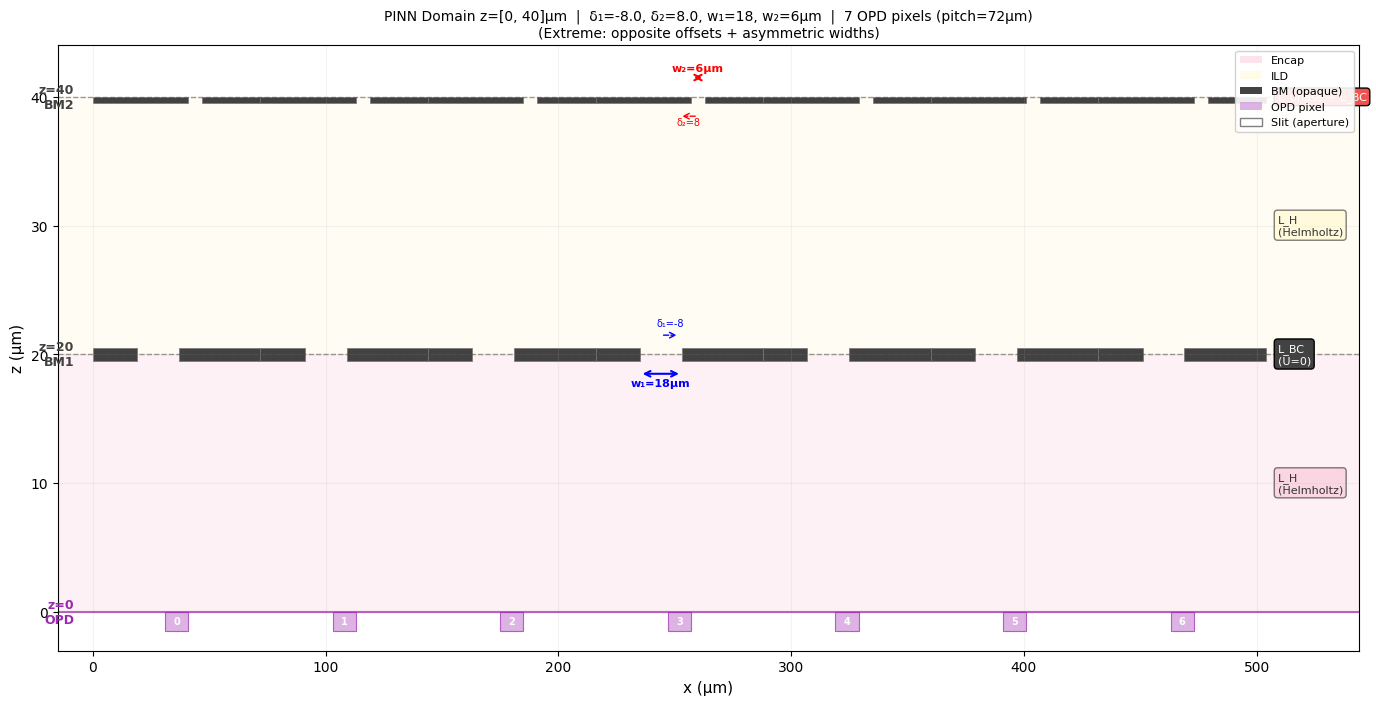

In [7]:
fig, ax = plot_pinn_domain(
    delta_bm1=-8, delta_bm2=8, w1=18, w2=6,
    figsize=(14, 7)
)
ax.set_title(ax.get_title() + '\n(Extreme: opposite offsets + asymmetric widths)',
             fontsize=10)
plt.show()

---
## Summary

| Parameter | Range | Effect |
|-----------|-------|--------|
| δ₁ (BM1 offset) | [-10, 10] μm | BM1 slit 좌우 이동 → PSF 비대칭 |
| δ₂ (BM2 offset) | [-10, 10] μm | BM2 slit 좌우 이동 → 입사광 비대칭 |
| w₁ (BM1 width) | [5, 20] μm | BM1 아퍼처 크기 → 회절 패턴 변화 |
| w₂ (BM2 width) | [5, 20] μm | BM2 아퍼처 크기 → 입사광 양 제어 |

PINN은 이 4개 설계변수에 대해 **파라메트릭**하게 학습합니다.
→ 임의의 (δ₁, δ₂, w₁, w₂) 조합에서 U(x, z)를 예측할 수 있어야 함.